# Using the symbolic regression model

While in the [quickstart notebook](./quickstart.ipynb) we have talked about ML models stored on Hugging Face, this package also offers a symbolic regression model, i.e. a data-driven analytical model defined by a set of equations.

In [1]:
import mammos_ai
import mammos_entity as me
import matplotlib.pyplot as plt
import numpy as np
import requests

## The model equations

This model was trained on hard magnet-only simulated data for single grain cubic particles with $L = 50$ nm edge length, and external field parallel to the anisotropy axis.

It gives analytical equations for the extrinsic properties $H_{\mathrm{c}}$, $M_{\mathrm{r}}$, $BH_{\mathrm{max}}$ from intrinsic properties $Ms$, $A$, and $K$.

The model works with the following rescaling quantities:

- the anisotropy field $H_{\mathrm{A}}$:

  $$
  H_{\mathrm{A}} := \frac{2K}{\mu_0 M_{\mathrm{s}}}
  $$

- the energy product scaling variable $BH_{\mathrm{s}}$:

  $$
  BH_{\mathrm{s}} := \frac{\mu_0 M_{\mathrm{s}}^2}{4}
  $$

- the hardness parameter $\kappa$:

  $$
  \kappa := \sqrt{\frac{K}{\mu_0 M_{\mathrm{s}}^2}}
  $$

- the exchange length $\ell_{\mathrm{ex}}$:

  $$
  \ell_{\mathrm{ex}} := \sqrt{\frac{2 A}{\mu_0 M_{\mathrm{s}}^2}}
  $$

- the reduced grain size $\tilde{L}$:

  $$
  \tilde{L} := \frac{L}{\ell_{\mathrm{ex}}}
  $$

Then, the model is defined by the following equations:

$$
H_\mathrm{c} &= \left[\alpha - n\,\frac{\ln\tilde{L}}{\kappa}\right] H_\mathrm{A}, \\ 
M_\mathrm{r} &= \left(1 - \varepsilon_m \frac{\tilde{L}}{\kappa^4}\right) M_\mathrm{s}, \\
BH_\mathrm{max} &= \left(1 - \varepsilon_b \frac{\tilde{L}}{\kappa^4}\right)^{\!2} BH_{\mathrm{s}},
$$

with fitted constants $\alpha = 0.942$, $n = 0.0921$, $\varepsilon_m = 5.18 \times 10^{-5}$, and $\varepsilon_b = 7.81 \times 10^{-5}$.

## Use the model via `mammos_ai`

The model has the same interface as the `random_forest` models and only the model string needs to be specified.

In [2]:
Ms = me.Ms(1e6)
A = me.A(1e-12)
K = me.Ku(1e6)

extrinsic = mammos_ai.Hc_Mr_BHmax_from_Ms_A_K(Ms, A, K, model="cube50_singlegrain_symbolic_regression_v1.0")
extrinsic

ExtrinsicProperties(Hc=Entity(ontology_label='CoercivityHcExternal', value=np.float64(894604.3352842493), unit='A / m'), Mr=Entity(ontology_label='Remanence', value=np.float64(996758.0267515216), unit='A / m'), BHmax=Entity(ontology_label='MaximumEnergyProduct', value=np.float64(311095.55410614907), unit='J / m3'))

We can access the individual extrinsic properties as follows:

In [3]:
extrinsic.Hc

Entity(ontology_label='CoercivityHcExternal', value=np.float64(894604.3352842493), unit='A / m')

In [4]:
extrinsic.Mr

Entity(ontology_label='Remanence', value=np.float64(996758.0267515216), unit='A / m')

In [5]:
extrinsic.BHmax

Entity(ontology_label='MaximumEnergyProduct', value=np.float64(311095.55410614907), unit='J / m3')

Differently from the `random_forest` models, this function does not check if the sample is a hard magnet based on the intrinsic properties. Therefore it might give physically wrong values for any of the extrinsic properties if used with a set of parameter inside the training range but still relating to soft magnets.

As with the other models, the metadata can be accessed as follows:

In [6]:
mammos_ai.Hc_Mr_BHmax_from_Ms_A_K_metadata(model="cube50_singlegrain_symbolic_regression_v1.0")

{'model_name': 'cube50_singlegrain_symbolic_regression_v1.0',
 'description': 'Symbolic regression model trained on extended simulated data for single grain cubic particles with 50 nm edge length with the external field applied parallel to the anisotropy axis.',
 'training_data_range': {'Ms': (Entity(ontology_label='SpontaneousMagnetization', value=np.float64(79577.47150262764), unit='A / m'),
   Entity(ontology_label='SpontaneousMagnetization', value=np.float64(3978873.5751313814), unit='A / m')),
  'A': (Entity(ontology_label='ExchangeStiffnessConstant', value=np.float64(1e-13), unit='J / m'),
   Entity(ontology_label='ExchangeStiffnessConstant', value=np.float64(1e-11), unit='J / m')),
  'K': (Entity(ontology_label='UniaxialAnisotropyConstant', value=np.float64(10000.0), unit='J / m3'),
   Entity(ontology_label='UniaxialAnisotropyConstant', value=np.float64(10000000.0), unit='J / m3'))},
 'input_parameters': ['Ms (A/m)', 'A (J/m)', 'K1 (J/m^3)'],
 'output_parameters': ['Hc (A/m)', '

```{note}
The symbolic regression model does not have a hard magnet classifier model nor a function `is_hard_magnet_from_Ms_A_K`.
```

## Comparison with random forest

We load the [simulation data for the random forest v1.0](https://github.com/MaMMoS-project/ML-models/tree/main/beyond-stoner-wohlfarth/single-grain-easy-axis-model). We compare the error in extrinsic properties for the random forest (RF) model v1.0 and the symbolic regression (SR) model.

In [7]:
res = requests.get(
    "https://raw.githubusercontent.com/MaMMoS-project/ML-models/refs/heads/main/beyond-stoner-wohlfarth/single-grain-easy-axis-model/data/single_grain_cube_50nm_aligned.csv"
)
with open("data.csv", "w") as f:
    f.write(res.text)
data = me.from_csv("data.csv")
data

EntityCollection(
    description='Micromagnetic hysteresis simulations of a 50 nm single-grain cube with randomly sampled Ms, A, and K1. Applied field and anisotropy axis aligned with the cube edge. Source: https://github.com/MaMMoS-project/BSW_data_generation',
    Ms=Entity(ontology_label='SpontaneousMagnetization', value=array([3067036.41017098 2970993.89080065 679871.29428583 ... 789641.83143586 948696.6396304 265828.51692313]) (shape=(12012,)), unit='A / m'),
    A=Entity(ontology_label='ExchangeStiffnessConstant', value=array([8.43874527e-12 7.62763633e-12 3.33284837e-12 ... 3.64928884e-12 8.47223285e-12 1.29441565e-12]) (shape=(12012,)), unit='J / m'),
    K1=Entity(ontology_label='UniaxialAnisotropyConstant', value=array([5675844.7803609 3044310.13380853 2040252.95416996 ... 120472.74871775 67863.49150036 699257.11275545]) (shape=(12012,)), unit='J / m3'),
    D=Entity(ontology_label='DemagnetizingFactor', value=array([0.33333333 0.33333333 0.33333333 ... 0.33333333 0.33333333 0.33333333]) (shape=(12012,))),
    Hc=Entity(ontology_label='CoercivityHcExternal', value=array([1199601.39711669 419724.57978837 3941062.65442692 ... 5.35447723e+04 3.65042395e+02 3.67447413e+06]) (shape=(12012,)), unit='A / m'),
    Mr=Entity(ontology_label='Remanence', value=array([3041986.39292324 2894615.02798736 679658.77285921 ... 761366.79342866 1765.76429323 265779.45406709]) (shape=(12012,)), unit='A / m'),
    BHmax=Entity(ontology_label='MaximumEnergyProduct', value=array([2884143.30980222 2500391.93601877 145112.8145537 ... 168217.86512804 193725.2095695 22191.28344111]) (shape=(12012,)), unit='N / m2'),
    filepath=<StringArray>
[   'data/346982_0_0/parameters.yaml',    'data/346982_0_1/parameters.yaml',
    'data/346982_0_2/parameters.yaml',    'data/346982_0_3/parameters.yaml',
 'data/346982_1000_0/parameters.yaml', 'data/346982_1000_1/parameters.yaml',
 'data/346982_1000_2/parameters.yaml', 'data/346982_1000_3/parameters.yaml',
  'data/346982_100_0/parameters.yaml',  'data/346982_100_1/parameters.yaml',
 ...
  'data/348612_999_2/parameters.yaml',  'data/348612_999_3/parameters.yaml',
   'data/348612_99_0/parameters.yaml',   'data/348612_99_1/parameters.yaml',
   'data/348612_99_2/parameters.yaml',   'data/348612_99_3/parameters.yaml',
    'data/348612_9_0/parameters.yaml',    'data/348612_9_1/parameters.yaml',
    'data/348612_9_2/parameters.yaml',    'data/348612_9_3/parameters.yaml']
Length: 12012, dtype: str,
)

Extract dataframe

In [8]:
df = data.to_dataframe()
metadata = data.metadata()
df

,Ms,A,K1,D,Hc,Mr,BHmax,filepath
0,3.067036e+06,8.438745e-12,5.675845e+06,0.333333,1.199601e+06,3.041986e+06,2.884143e+06,data/346982_0_0/parameters.yaml
1,2.970994e+06,7.627636e-12,3.044310e+06,0.333333,4.197246e+05,2.894615e+06,2.500392e+06,data/346982_0_1/parameters.yaml
2,6.798713e+05,3.332848e-12,2.040253e+06,0.333333,3.941063e+06,6.796588e+05,1.451128e+05,data/346982_0_2/parameters.yaml
3,2.373693e+06,6.120197e-12,3.159147e+06,0.333333,8.613933e+05,2.351641e+06,1.720225e+06,data/346982_0_3/parameters.yaml
4,1.528379e+06,4.290345e-12,3.911766e+06,0.333333,2.719548e+06,1.526489e+06,7.318034e+05,data/346982_1000_0/parameters.yaml
...,...,...,...,...,...,...,...,...
12007,1.718878e+06,4.995278e-12,1.005005e+06,0.333333,3.162383e+05,1.679114e+06,8.490428e+05,data/348612_99_3/parameters.yaml
12008,1.625237e+06,4.226911e-12,7.125370e+05,0.333333,1.849053e+05,1.566629e+06,7.180755e+05,data/348612_9_0/parameters.yaml
12009,7.896418e+05,3.649289e-12,1.204727e+05,0.333333,5.354477e+04,7.613668e+05,1.682179e+05,data/348612_9_1/parameters.yaml
12010,9.486966e+05,8.472233e-12,6.786349e+04,0.333333,3.650424e+02,1.765764e+03,1.937252e+05,data/348612_9_2/parameters.yaml


In [9]:
df_valid = df.dropna()
df_valid

,Ms,A,K1,D,Hc,Mr,BHmax,filepath
0,3.067036e+06,8.438745e-12,5.675845e+06,0.333333,1.199601e+06,3.041986e+06,2.884143e+06,data/346982_0_0/parameters.yaml
1,2.970994e+06,7.627636e-12,3.044310e+06,0.333333,4.197246e+05,2.894615e+06,2.500392e+06,data/346982_0_1/parameters.yaml
2,6.798713e+05,3.332848e-12,2.040253e+06,0.333333,3.941063e+06,6.796588e+05,1.451128e+05,data/346982_0_2/parameters.yaml
3,2.373693e+06,6.120197e-12,3.159147e+06,0.333333,8.613933e+05,2.351641e+06,1.720225e+06,data/346982_0_3/parameters.yaml
4,1.528379e+06,4.290345e-12,3.911766e+06,0.333333,2.719548e+06,1.526489e+06,7.318034e+05,data/346982_1000_0/parameters.yaml
...,...,...,...,...,...,...,...,...
12007,1.718878e+06,4.995278e-12,1.005005e+06,0.333333,3.162383e+05,1.679114e+06,8.490428e+05,data/348612_99_3/parameters.yaml
12008,1.625237e+06,4.226911e-12,7.125370e+05,0.333333,1.849053e+05,1.566629e+06,7.180755e+05,data/348612_9_0/parameters.yaml
12009,7.896418e+05,3.649289e-12,1.204727e+05,0.333333,5.354477e+04,7.613668e+05,1.682179e+05,data/348612_9_1/parameters.yaml
12010,9.486966e+05,8.472233e-12,6.786349e+04,0.333333,3.650424e+02,1.765764e+03,1.937252e+05,data/348612_9_2/parameters.yaml


### Comparing all valid points

These are all valid points and their RF and SR estimates:

In [10]:
data_valid = me.EntityCollection.from_dataframe(df_valid, metadata)
valid_rf = mammos_ai.Hc_Mr_BHmax_from_Ms_A_K(
    data_valid.Ms, data_valid.A, data_valid.K1, model="cube50_singlegrain_random_forest_v1.0"
)
valid_sr = mammos_ai.Hc_Mr_BHmax_from_Ms_A_K(
    data_valid.Ms, data_valid.A, data_valid.K1, model="cube50_singlegrain_symbolic_regression_v1.0"
)

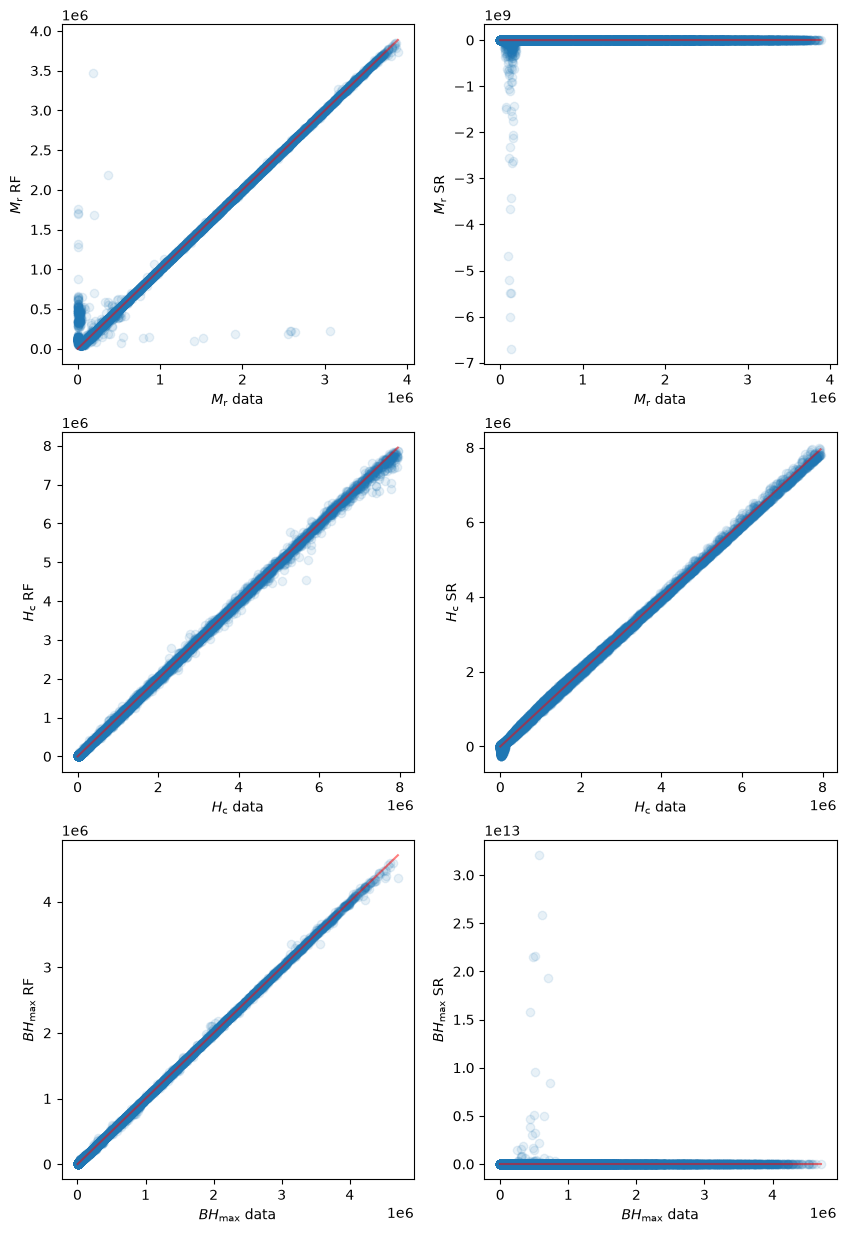

In [16]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))
alpha = 0.1

# Mr
ax[0, 0].scatter(data_valid.Mr.q, valid_rf.Mr.q, alpha=alpha)
ax[0, 0].plot(
    (np.nanmin(data_valid.Mr.value), np.nanmax(data_valid.Mr.value)),
    (np.nanmin(data_valid.Mr.value), np.nanmax(data_valid.Mr.value)),
    "r",
    alpha=0.5,
)
ax[0, 0].set_xlabel(r"$M_{\mathsf{r}}$ data")
ax[0, 0].set_ylabel(r"$M_{\mathsf{r}}$ RF")
ax[0, 1].scatter(data_valid.Mr.q, valid_sr.Mr.q, alpha=alpha)
ax[0, 1].set_xlabel(r"$M_{\mathsf{r}}$ data")
ax[0, 1].set_ylabel(r"$M_{\mathsf{r}}$ SR")
ax[0, 1].plot(
    (np.nanmin(data_valid.Mr.value), np.nanmax(data_valid.Mr.value)),
    (np.nanmin(data_valid.Mr.value), np.nanmax(data_valid.Mr.value)),
    "r",
    alpha=0.5,
)

# Hc
ax[1, 0].scatter(data_valid.Hc.q, valid_rf.Hc.q, alpha=alpha)
ax[1, 0].plot(
    (np.nanmin(data_valid.Hc.value), np.nanmax(data_valid.Hc.value)),
    (np.nanmin(data_valid.Hc.value), np.nanmax(data_valid.Hc.value)),
    "r",
    alpha=0.5,
)
ax[1, 0].set_xlabel(r"$H_{\mathsf{c}}$ data")
ax[1, 0].set_ylabel(r"$H_{\mathsf{c}}$ RF")
ax[1, 1].scatter(data_valid.Hc.q, valid_sr.Hc.q, alpha=alpha)
ax[1, 1].plot(
    (np.nanmin(data_valid.Hc.value), np.nanmax(data_valid.Hc.value)),
    (np.nanmin(data_valid.Hc.value), np.nanmax(data_valid.Hc.value)),
    "r",
    alpha=0.5,
)
ax[1, 1].set_xlabel(r"$H_{\mathsf{c}}$ data")
ax[1, 1].set_ylabel(r"$H_{\mathsf{c}}$ SR")

# BHmax
ax[2, 0].scatter(data_valid.BHmax.q, valid_rf.BHmax.q, alpha=alpha)
ax[2, 0].plot(
    (np.nanmin(data_valid.BHmax.value), np.nanmax(data_valid.BHmax.value)),
    (np.nanmin(data_valid.BHmax.value), np.nanmax(data_valid.BHmax.value)),
    "r",
    alpha=0.5,
)
ax[2, 0].set_xlabel(r"$BH_{\mathsf{max}}$ data")
ax[2, 0].set_ylabel(r"$BH_{\mathsf{max}}$ RF")
ax[2, 1].scatter(data_valid.BHmax.q, valid_sr.BHmax.q, alpha=alpha)
ax[2, 1].plot(
    (np.nanmin(data_valid.BHmax.value), np.nanmax(data_valid.BHmax.value)),
    (np.nanmin(data_valid.BHmax.value), np.nanmax(data_valid.BHmax.value)),
    "r",
    alpha=0.5,
)
ax[2, 1].set_xlabel(r"$BH_{\mathsf{max}}$ data")
ax[2, 1].set_ylabel(r"$BH_{\mathsf{max}}$ SR")

plt.show()

We observe an occasional negative $M_{\mathsf{r}}$ value, which is unphysical. We assume this is an effect of applying the symbolic regression model to soft magnet materials, and this model is only valid for hard magnets.

### Comparing only hard valid points

We select hard points based on the threshold $Mr/Ms > 0.4$ (as described in the training repository).

In [12]:
df_hard = df_valid[df_valid.Mr / df_valid.Ms > 0.4]
df_hard

,Ms,A,K1,D,Hc,Mr,BHmax,filepath
0,3.067036e+06,8.438745e-12,5.675845e+06,0.333333,1.199601e+06,3.041986e+06,2.884143e+06,data/346982_0_0/parameters.yaml
1,2.970994e+06,7.627636e-12,3.044310e+06,0.333333,4.197246e+05,2.894615e+06,2.500392e+06,data/346982_0_1/parameters.yaml
2,6.798713e+05,3.332848e-12,2.040253e+06,0.333333,3.941063e+06,6.796588e+05,1.451128e+05,data/346982_0_2/parameters.yaml
3,2.373693e+06,6.120197e-12,3.159147e+06,0.333333,8.613933e+05,2.351641e+06,1.720225e+06,data/346982_0_3/parameters.yaml
4,1.528379e+06,4.290345e-12,3.911766e+06,0.333333,2.719548e+06,1.526489e+06,7.318034e+05,data/346982_1000_0/parameters.yaml
...,...,...,...,...,...,...,...,...
12006,4.672497e+05,3.392154e-13,5.230676e+04,0.333333,3.841750e+04,4.463979e+05,5.654758e+04,data/348612_99_2/parameters.yaml
12007,1.718878e+06,4.995278e-12,1.005005e+06,0.333333,3.162383e+05,1.679114e+06,8.490428e+05,data/348612_99_3/parameters.yaml
12008,1.625237e+06,4.226911e-12,7.125370e+05,0.333333,1.849053e+05,1.566629e+06,7.180755e+05,data/348612_9_0/parameters.yaml
12009,7.896418e+05,3.649289e-12,1.204727e+05,0.333333,5.354477e+04,7.613668e+05,1.682179e+05,data/348612_9_1/parameters.yaml


In [13]:
data_hard = me.EntityCollection.from_dataframe(df_hard, metadata)
hard_rf = mammos_ai.Hc_Mr_BHmax_from_Ms_A_K(
    data_hard.Ms, data_hard.A, data_hard.K1, model="cube50_singlegrain_random_forest_v1.0"
)
hard_sr = mammos_ai.Hc_Mr_BHmax_from_Ms_A_K(
    data_hard.Ms, data_hard.A, data_hard.K1, model="cube50_singlegrain_symbolic_regression_v1.0"
)

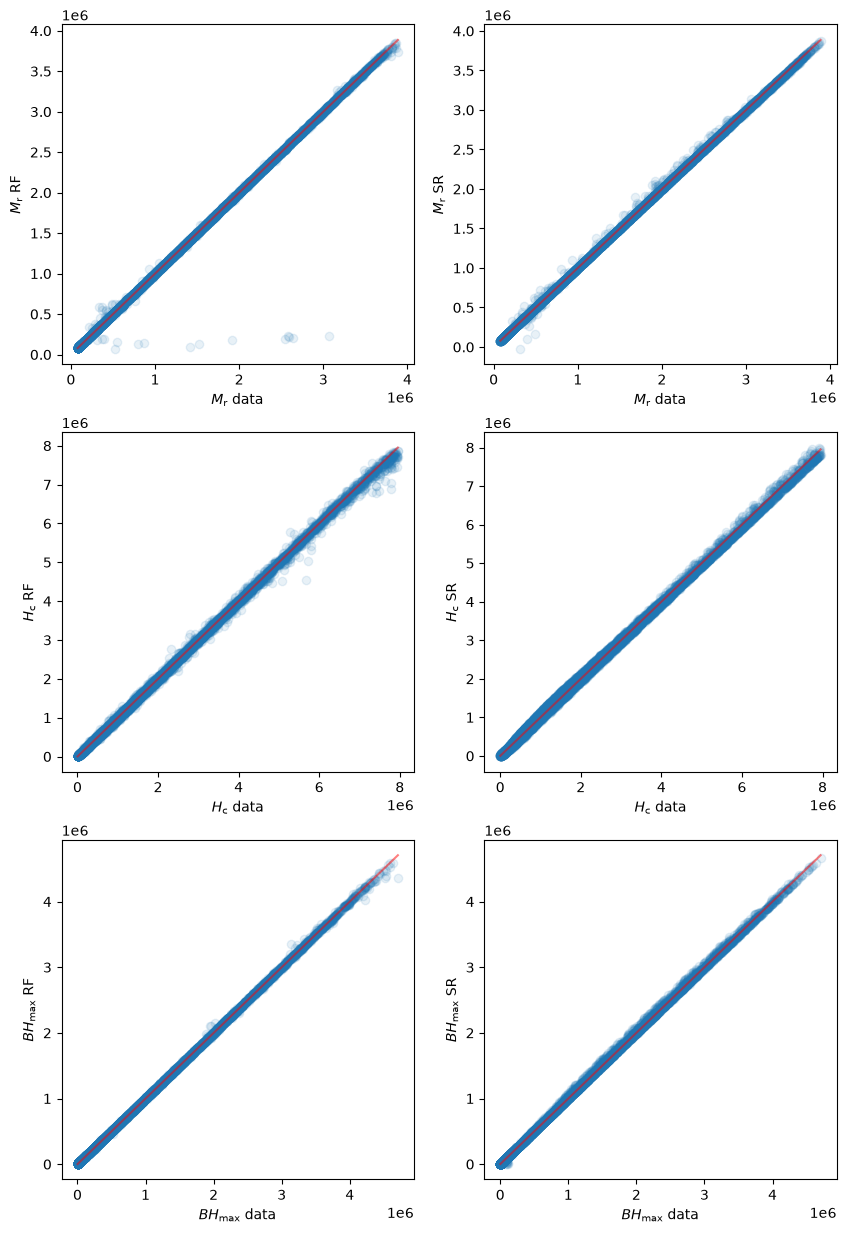

In [15]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))
alpha = 0.1

# Mr
ax[0, 0].scatter(data_hard.Mr.q, hard_rf.Mr.q, alpha=alpha)
ax[0, 0].plot(
    (np.nanmin(data_hard.Mr.value), np.nanmax(data_hard.Mr.value)),
    (np.nanmin(data_hard.Mr.value), np.nanmax(data_hard.Mr.value)),
    "r",
    alpha=0.5,
)
ax[0, 0].set_xlabel(r"$M_{\mathsf{r}}$ data")
ax[0, 0].set_ylabel(r"$M_{\mathsf{r}}$ RF")
ax[0, 1].scatter(data_hard.Mr.q, hard_sr.Mr.q, alpha=alpha)
ax[0, 1].set_xlabel(r"$M_{\mathsf{r}}$ data")
ax[0, 1].set_ylabel(r"$M_{\mathsf{r}}$ SR")
ax[0, 1].plot(
    (np.nanmin(data_hard.Mr.value), np.nanmax(data_hard.Mr.value)),
    (np.nanmin(data_hard.Mr.value), np.nanmax(data_hard.Mr.value)),
    "r",
    alpha=0.5,
)

# Hc
ax[1, 0].scatter(data_hard.Hc.q, hard_rf.Hc.q, alpha=alpha)
ax[1, 0].plot(
    (np.nanmin(data_hard.Hc.value), np.nanmax(data_hard.Hc.value)),
    (np.nanmin(data_hard.Hc.value), np.nanmax(data_hard.Hc.value)),
    "r",
    alpha=0.5,
)
ax[1, 0].set_xlabel(r"$H_{\mathsf{c}}$ data")
ax[1, 0].set_ylabel(r"$H_{\mathsf{c}}$ RF")
ax[1, 1].scatter(data_hard.Hc.q, hard_sr.Hc.q, alpha=alpha)
ax[1, 1].plot(
    (np.nanmin(data_hard.Hc.value), np.nanmax(data_hard.Hc.value)),
    (np.nanmin(data_hard.Hc.value), np.nanmax(data_hard.Hc.value)),
    "r",
    alpha=0.5,
)
ax[1, 1].set_xlabel(r"$H_{\mathsf{c}}$ data")
ax[1, 1].set_ylabel(r"$H_{\mathsf{c}}$ SR")

# BHmax
ax[2, 0].scatter(data_hard.BHmax.q, hard_rf.BHmax.q, alpha=alpha)
ax[2, 0].plot(
    (np.nanmin(data_hard.BHmax.value), np.nanmax(data_hard.BHmax.value)),
    (np.nanmin(data_hard.BHmax.value), np.nanmax(data_hard.BHmax.value)),
    "r",
    alpha=0.5,
)
ax[2, 0].set_xlabel(r"$BH_{\mathsf{max}}$ data")
ax[2, 0].set_ylabel(r"$BH_{\mathsf{max}}$ RF")
ax[2, 1].scatter(data_hard.BHmax.q, hard_sr.BHmax.q, alpha=alpha)
ax[2, 1].plot(
    (np.nanmin(data_hard.BHmax.value), np.nanmax(data_hard.BHmax.value)),
    (np.nanmin(data_hard.BHmax.value), np.nanmax(data_hard.BHmax.value)),
    "r",
    alpha=0.5,
)
ax[2, 1].set_xlabel(r"$BH_{\mathsf{max}}$ data")
ax[2, 1].set_ylabel(r"$BH_{\mathsf{max}}$ SR")

plt.show()

The symbolic regression on hard magnets seems to be even more accurate than the random forest model.